# Dokumentasjon på funksjon for å avstand-score

For å kunne sammenligne resultatene fra foreldreundersøkelsen med avstand fra hjemadresse må man bruke et sammenlignbart poengsystem. Foreldreundersøkelsen gir barnehagene poeng på en skala fra 0-5. Det er naturlig å bruke den samme skalaen for avstand. 

I tillegg er nødvendig å gjøre enda en avgresning. Svarene i foreldreundersøkelsen viser at foreldre i liten grad bruker hele skalaen. I 2026 var den høyste scoren for total tilfredshet 5, mens den laveste var 3,4. Funksjonen vi konstruerer må derfor være lik 5 når avstand er lik 0 og lik 3.4 når avstand går mot uendlig. I praksis burde scoren gå mot 3,4 lenge før avstand når uendelig. Spørsmålet er imidlertid hvor raskt den skal gå mot 3,4. 

Det er ikke selfølgelig hvordan dette skal gjøres, og det finnes mange alternativer. Det nødvendig å bestemme seg for hvilken type funksjon vi skal bruke, og hvor raskt den skal falle. Det siste bestemmes av hvilke parametere vi bruker i funksjonen. 

I dette dokumentet ser jeg nærmere på én type funksjon. Jeg fokuserer i hovedsak på parameteret vi kan fininnstille for å gi funksjonen de egenskapene som er ønskelige. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, FloatSlider
import ipympl
from IPython.display import clear_output
from geo_func import avstand_score

In [2]:
df = pd.read_parquet("data/foreldreundersokelse_geo.parquet",
                     engine = "pyarrow")

In [3]:
def plot_avstand(log_k=-4):
    parameter = 10**log_k
    clear_output(wait=True)
    plt.figure(figsize=(8,4))
    x = np.linspace(0, 15000, 15001)
    plt.plot(x, 3.4+(1.6/(1+x*parameter)))
    plt.xlabel("Avstand")
    plt.ylabel("Score")
    plt.title(f"parameter = {parameter:.4f}")
    plt.show()

interact(plot_avstand, log_k=FloatSlider(value=-4, min=-4, max=0, step=0.1, readout_format='.1f', continuous_update=False))

interactive(children=(FloatSlider(value=-4.0, continuous_update=False, description='log_k', max=0.0, min=-4.0,…

<function __main__.plot_avstand(log_k=-4)>

Figuren over plotter funksjonen: 

$f(Avstand) = 3.4 + \frac{1.6}{1+k \cdot Avstand}$

Funksjonen innehar de nødvendige egenskapene vi er ute etter. Når avstand fra hjemadresse er 0, får barnehagen den høyest mulige poengsummen. Ettersom avstanden øker, faller poengsummen. Når $Avstand \to \infty$, går poengsummen mot 3. 

Hvor raskt funksjonen går mot 3 avhenger av parameteret $k$. Større $k$ gjør at poengsummmen går raskere mot 3. Dette kan man se av funksjonens deriverte: $f'(Avstand) = -\frac{2k}{(1+k \cdot Avstand)^2}$. Når $k$ nærmer seg 1, vil bare en liten endringen i avstanden fra hjemadresse resultere i en poengsum nær 3. Den deriverte er plottet i figuren under. Funksjonen stiger ettersom $avstand$ vokser. Når $k$ er større, skjer dette raskere, og når $k = 1$, har vi en "Leontiefaktig"-funksjon. Det vil si at figuren ser ut til å ha en 90-graders vinkel når $f(Avstand = 0)$ (funksjonen er fortsatt deriverbar i dette punktet, men det ser ikke slik ut med dimensjonene på x-aksen).

In [4]:
def plot_derivert(log_k=-4):
    parameter = 10**log_k
    clear_output(wait=True)
    plt.figure(figsize=(8,4))
    x = np.linspace(0, 15000, 15001)
    plt.plot(x, -2*parameter/(1+x*parameter)**2)
    plt.xlabel("Avstand")
    plt.ylabel("Score")
    plt.title(f"parameter = {parameter:.4f}")
    plt.show()

interact(plot_derivert, log_k=FloatSlider(value=-4, min=-4, max=0, step=0.1, readout_format='.1f', continuous_update=False))

interactive(children=(FloatSlider(value=-4.0, continuous_update=False, description='log_k', max=0.0, min=-4.0,…

<function __main__.plot_derivert(log_k=-4)>

Spørsmålet som må besvares er hvilken verdi på k vi skal sette. Dette vil i stor grad påvirke poengsummen de ulike barnehagene blir tildelt, og dermed også rangeringen av barnehager. Figruene under viser fordelingen av scoren på tilfredshet og avstanden fra hjemadresse i meter. Figuren til venstre viser at det svært mange barnehager som har en høy score på tilfredshet. Flertallet av barnehager har faktisk en score over 4.5. 

Figuren til høyre viser fordelingen av barnehagens avstand fra hjem. Naturlig nok ligger de fleste barnehager et godt stykke fra der vi bor. Det er likevel over 60 barnehager i datasettet som ligger under 2 kilometer fra oss. Funksjonen vi konstruerer burde derfor straffe avstand ganske hardt. Det er også viktig at funksjonen klarer å skille mellom barnehager som ligger i nærheten. Alle foreldre vet at det stor forskjell på å gå 500 meter med og uten barn. 

Når man sammenstiller informasjonen fra de to figurene er det klart at det bare er svært liten andel av barnehagene som er aktuelle å søke på. Selv om man bare vurderer de 50 nærmeste barnehagene, vil det være barnehager med nær full score fra foreldreundersøkelsen. Av barnehagene som ligger under 2 kilometer fra oss, hadde for eksempel 10 barnehager en score på 4.8 eller høyere. Når man i etterkant vurderer om funksjonen er passende, kan man kontrollere at det kun er barnehager i nærheten som faktisk kommer best ut.  

In [5]:
%matplotlib inline

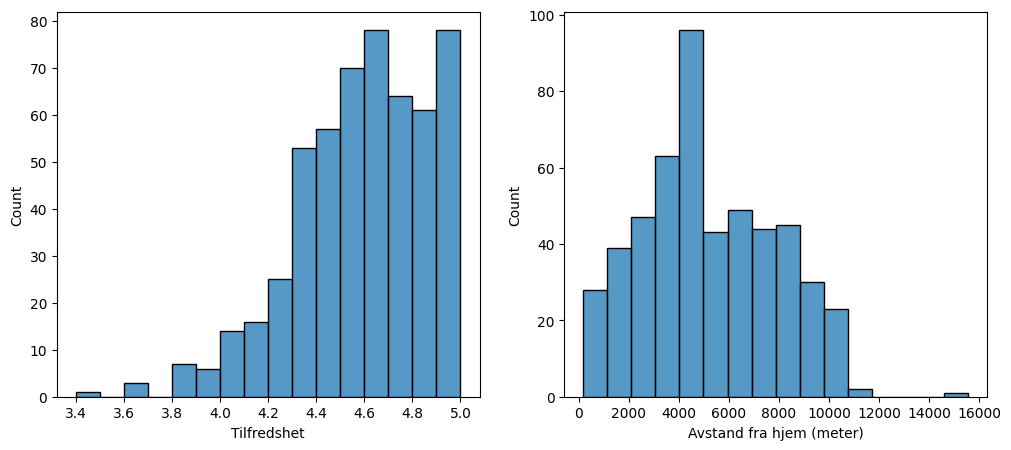

In [6]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.histplot(data=df,
             x="Tilfredshet",
             binwidth=0.1,
             ax = axes[0],
            )
sns.histplot(data=df,
             x="Avstand_hjem_m",
             ax = axes[1]
            )
axes[1].set_xlabel("Avstand fra hjem (meter)")
plt.show()

De seks histogrammene under viser fordelingen av scoren på avstand for ulike verdier av k. Med en $k=0.0001$ scorer alle barnehagene mellom 4 og 5. Ettersom k vokser, faller den gjennomsnittlige scoren. En større del av skalene blir også brukt. Basert på dette ser til ut at en k-verdi på mellom 0.0003 og 0.0009 virker fornuftig. 

Som beskrevet over er det viktig at funksjonen vi lander på også klarer å poengi barnehager i umidelbar nærhet på en god måte. De neste seks figurene plotter kun barnehager som er nærmere en to kilometer. Figurene bekrefter en k-verdi på 0.0001 i for liten grad straffer avstand. En k-verdi på 0.0009 vurderes til å være for "streng". De mest akutelle k-verdiene ser for ut til å ligger rundt 0.0005 og 0.0007. Jeg har valgt å bruke 0.0005. 

Det er viktig å understreke at nok finnes bedre metoder for å komme frem "riktig" k-verdi. Jeg har valgt å bruke en k-verdi som gir mening for meg, men dette holder ikke som metode i en fagfellevurdert vitenskaplig artikkel. I rangeringen legger jeg også inn en mulighet for å vekte avstandscoren. Dersom man mener at en annen k-verdi er riktigere, kan justere vektingen i den retningen. 

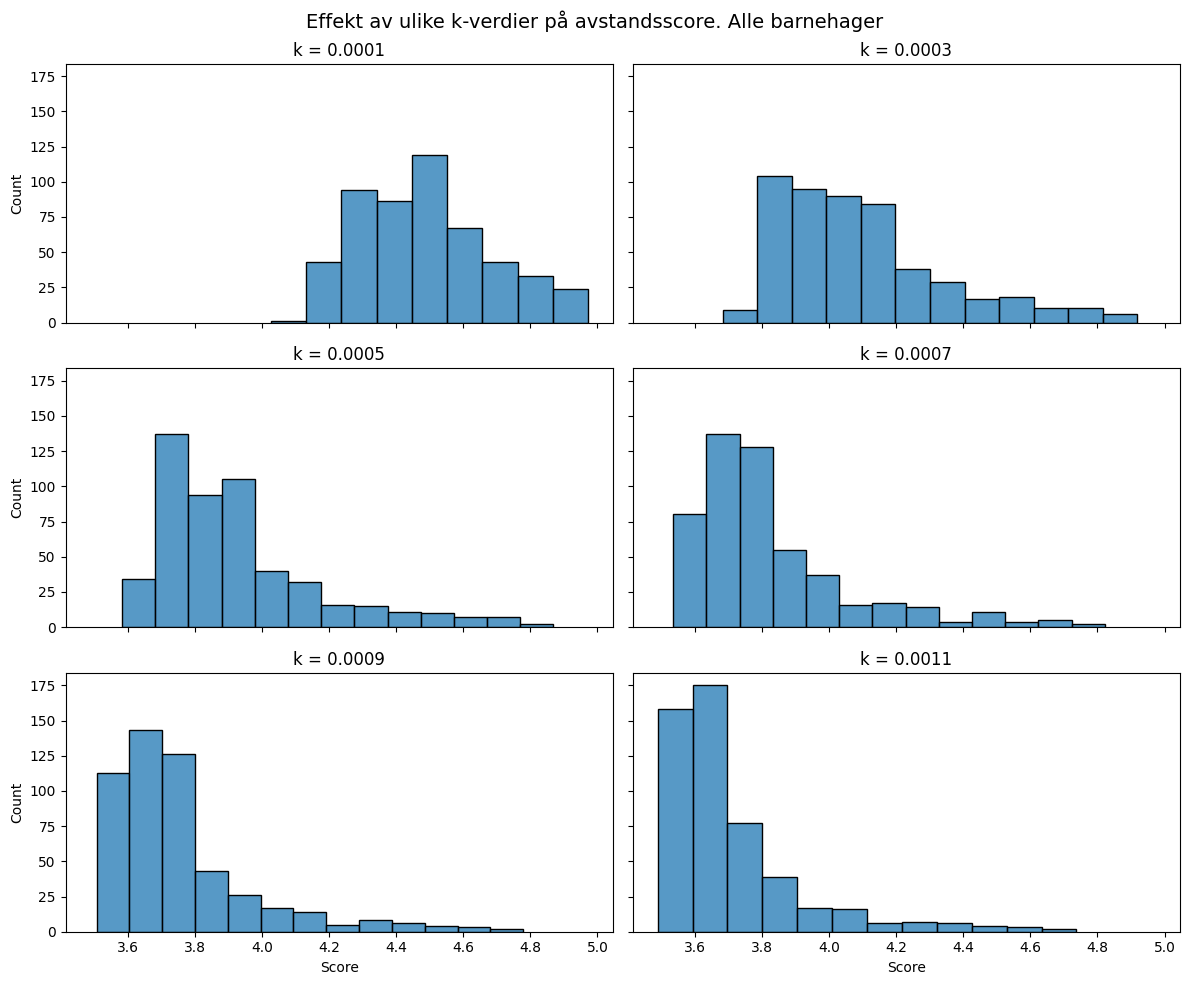

In [7]:
k_verdier = [0.0001, 0.0003, 0.0005, 0.0007, 0.0009, 0.0011]                            
              
fig, axes = plt.subplots(3, 2,
figsize=(12, 10), sharey=True, sharex=True)
axes = axes.flatten()

for ax, k in zip(axes, k_verdier):
  scores = avstand_score(df["Avstand_hjem_m"], min=df["Tilfredshet"].min(), maks=df["Tilfredshet"].max(), k=k)
  sns.histplot(scores, ax=ax, binwidth=0.1)
  ax.set_title(f"k = {k}")
  ax.set_xlabel("Score")

fig.suptitle("Effekt av ulike k-verdier på avstandsscore. Alle barnehager", fontsize=14)
plt.tight_layout()
plt.show()

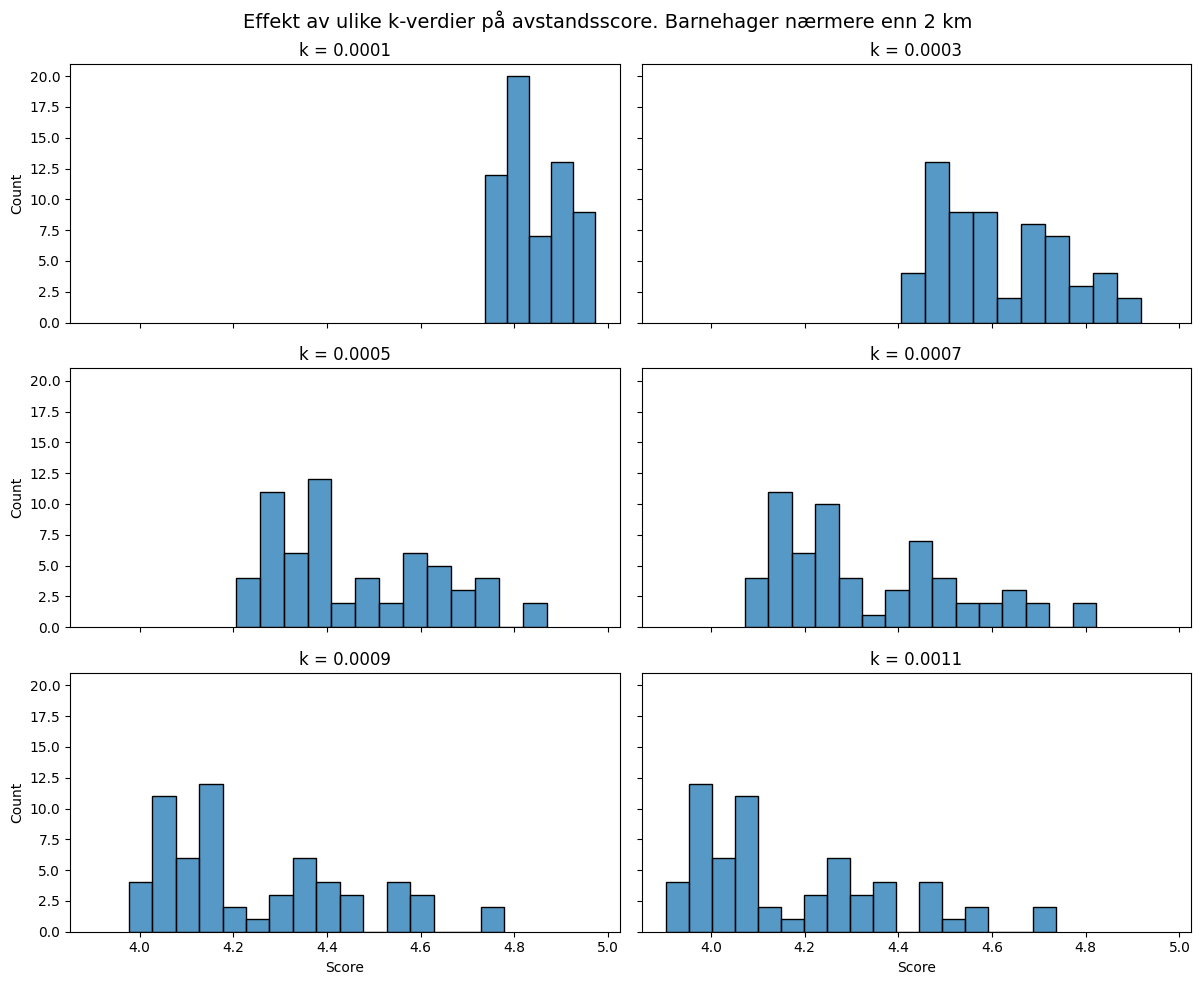

In [8]:
fig, axes = plt.subplots(3, 2,
figsize=(12, 10), sharey=True, sharex=True)
axes = axes.flatten()

for ax, k in zip(axes, k_verdier):
  scores = avstand_score(df.loc[df["Avstand_hjem_m"]<2000, "Avstand_hjem_m"], min=df["Tilfredshet"].min(), maks=df["Tilfredshet"].max(), k=k)
  sns.histplot(scores, ax=ax, binwidth=0.05)
  ax.set_title(f"k = {k}")
  ax.set_xlabel("Score")

fig.suptitle("Effekt av ulike k-verdier på avstandsscore. Barnehager nærmere enn 2 km", fontsize=14)
plt.tight_layout()
plt.show()